In [3]:
import os
import re

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from IPython.display import display


TRACKING_URI = "https://mlflow.rationai.cloud.e-infra.cz/"
CIAO_EXPERIMENT_NAME = "ucb-multiple-regions"
BASELINES_EXPERIMENT_NAME = "baselines-comparison-imagenet-s"

os.environ["MLFLOW_TRACKING_USERNAME"] = "YOUR_MLFLOW_USERNAME"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "YOUR_MLFLOW_PASSWORD"

WIN_MARGIN = 0.05  # min raw-value gap between 1st and 2nd place to count as decisive

mlflow.set_tracking_uri(TRACKING_URI)

## Load data

In [4]:
_CIAO_NAME_RE = re.compile(r"^(.+)-(\d+)-length-(\d+)$")


def _parse_ciao_label(name):
    if not isinstance(name, str):
        return None
    m = _CIAO_NAME_RE.match(name)
    return m.group(1) if m else None


def _first_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def load_ciao_metrics(experiment_name):
    """Per-(method, image) saliency metrics from CIAO algorithm runs.

    The same saliency metrics are logged to every desired-length child run for a
    given (method, image) pair; we deduplicate by taking the first non-null value.
    Returns columns: method, image_name, deletion_auc, insertion_auc, pointing_game, iou
    """
    exp = mlflow.get_experiment_by_name(experiment_name)
    if exp is None:
        raise RuntimeError(f"Experiment {experiment_name!r} not found.")

    runs = mlflow.search_runs(
        experiment_ids=[exp.experiment_id], output_format="pandas"
    )
    print(f"[CIAO] Total runs fetched: {len(runs)}")

    parents = runs[runs["tags.mlflow.parentRunId"].isna()].copy()
    children = runs[runs["tags.mlflow.parentRunId"].notna()].copy()

    parents["method"] = parents["tags.mlflow.runName"].apply(_parse_ciao_label)
    parents = parents[parents["method"].notna()]

    data = children.merge(
        parents[["run_id", "method"]],
        left_on="tags.mlflow.parentRunId",
        right_on="run_id",
        suffixes=("", "_parent"),
        how="inner",
    )
    data["image_name"] = data["tags.mlflow.runName"]

    del_col = _first_col(data, ["metrics.deletion_auc"])
    ins_col = _first_col(data, ["metrics.insertion_auc"])
    pg_col = _first_col(data, ["metrics.pointing_game"])
    iou_col = _first_col(data, ["metrics.iou"])

    data = data.copy()
    data["deletion_auc"] = data[del_col].astype(float) if del_col else np.nan
    data["insertion_auc"] = data[ins_col].astype(float) if ins_col else np.nan
    data["pointing_game"] = data[pg_col].astype(float) if pg_col else np.nan
    data["iou"] = data[iou_col].astype(float) if iou_col else np.nan

    # Each (method, image) appears once per desired_length â€” deduplicate
    deduped = (
        data.sort_values("run_id")
        .groupby(["method", "image_name"])[
            ["deletion_auc", "insertion_auc", "pointing_game", "iou"]
        ]
        .first()
        .reset_index()
    )

    methods_found = sorted(deduped["method"].unique())
    per_method = deduped.groupby("method")["image_name"].count().to_dict()
    print(f"[CIAO] Methods: {methods_found}")
    print(f"[CIAO] Images per method: {per_method}")
    return deduped


def load_baseline_metrics(experiment_name):
    """Per-(method, image) saliency metrics from baseline runs.

    Baselines log IoU as 'iou_top{fraction}' instead of 'iou' â€” remapped to 'iou'.
    Returns columns: method, image_name, deletion_auc, insertion_auc, pointing_game, iou
    """
    exp = mlflow.get_experiment_by_name(experiment_name)
    if exp is None:
        raise RuntimeError(f"Experiment {experiment_name!r} not found.")

    runs = mlflow.search_runs(
        experiment_ids=[exp.experiment_id], output_format="pandas"
    )
    print(f"[Baselines] Total runs fetched: {len(runs)}")

    parents = runs[runs["tags.mlflow.parentRunId"].isna()].copy()
    children = runs[runs["tags.mlflow.parentRunId"].notna()].copy()

    parents["method"] = parents["tags.mlflow.runName"]

    data = children.merge(
        parents[["run_id", "method"]],
        left_on="tags.mlflow.parentRunId",
        right_on="run_id",
        suffixes=("", "_parent"),
        how="inner",
    )
    data["image_name"] = data["tags.mlflow.runName"]

    del_col = _first_col(data, ["metrics.deletion_auc"])
    ins_col = _first_col(data, ["metrics.insertion_auc"])
    pg_col = _first_col(data, ["metrics.pointing_game"])
    # Baselines log IoU under iou_top{fraction} â€” try both keys
    iou_col = _first_col(data, ["metrics.iou", "metrics.iou_top0.0707"])

    data = data.copy()
    data["deletion_auc"] = data[del_col].astype(float) if del_col else np.nan
    data["insertion_auc"] = data[ins_col].astype(float) if ins_col else np.nan
    data["pointing_game"] = data[pg_col].astype(float) if pg_col else np.nan
    data["iou"] = data[iou_col].astype(float) if iou_col else np.nan

    result = data[
        [
            "method",
            "image_name",
            "deletion_auc",
            "insertion_auc",
            "pointing_game",
            "iou",
        ]
    ].copy()
    methods_found = sorted(result["method"].unique())
    per_method = result.groupby("method")["image_name"].count().to_dict()
    print(f"[Baselines] Methods: {methods_found}")
    print(f"[Baselines] Images per method: {per_method}")
    return result


ciao_df = load_ciao_metrics(CIAO_EXPERIMENT_NAME)
baselines_df = load_baseline_metrics(BASELINES_EXPERIMENT_NAME)
all_data = pd.concat([ciao_df, baselines_df], ignore_index=True)
ALGO_FILTER = "ucb"  # set to None to include all CIAO methods
if ALGO_FILTER:
    baseline_methods = set(baselines_df["method"].unique())
    all_data = all_data[
        all_data["method"].str.startswith(ALGO_FILTER)
        | all_data["method"].isin(baseline_methods)
    ]
n_methods = all_data["method"].nunique()
print(f"\nCombined: {len(all_data)} rows across {n_methods} methods")

[CIAO] Total runs fetched: 1212
[CIAO] Methods: ['ucb-2regions', 'ucb-3regions', 'ucb-4regions']
[CIAO] Images per method: {'ucb-2regions': 100, 'ucb-3regions': 100, 'ucb-4regions': 100}
[Baselines] Total runs fetched: 404
[Baselines] Methods: ['gradcampp', 'lime-slic', 'mp', 'occlusion']
[Baselines] Images per method: {'gradcampp': 100, 'lime-slic': 100, 'mp': 100, 'occlusion': 100}

Combined: 700 rows across 7 methods


In [5]:
print("Coverage â€” non-null metric values per method:")
coverage = (
    all_data.groupby("method")
    .agg(
        n_images=("image_name", "count"),
        del_n=("deletion_auc", lambda x: x.notna().sum()),
        ins_n=("insertion_auc", lambda x: x.notna().sum()),
        pg_n=("pointing_game", lambda x: x.notna().sum()),
        iou_n=("iou", lambda x: x.notna().sum()),
    )
    .rename(
        columns={
            "n_images": "Total images",
            "del_n": "Deletion AUC N",
            "ins_n": "Insertion AUC N",
            "pg_n": "Pointing game N",
            "iou_n": "IoU N",
        }
    )
)
display(coverage)

Coverage â€” non-null metric values per method:


,Total images,Deletion AUC N,Insertion AUC N,Pointing game N,IoU N
method,,,,,
gradcampp,100,100,100,99,99
lime-slic,100,100,100,99,99
mp,100,100,100,99,99
occlusion,100,100,100,99,99
ucb-2regions,100,87,87,86,99
ucb-3regions,100,100,100,99,99
ucb-4regions,100,100,100,99,99


## Analysis

In [6]:
def count_wins(df, metric_col, higher_is_better, margin=0.0):
    """Per-image win counts for each method on a single metric.

    Returns {method: {'wins': int, 'decisive': int}}
    decisive = gap between 1st and 2nd place > margin on the raw metric value.
    """
    result = {m: {"wins": 0, "decisive": 0} for m in df["method"].unique()}

    for _, grp in df.groupby("image_name"):
        valid = grp.dropna(subset=[metric_col])
        if len(valid) < 2:
            continue
        ranked = (
            valid.nlargest(len(valid), metric_col)
            if higher_is_better
            else valid.nsmallest(len(valid), metric_col)
        )
        winner = ranked.iloc[0]["method"]
        gap = abs(ranked.iloc[0][metric_col] - ranked.iloc[1][metric_col])
        result[winner]["wins"] += 1
        if gap > margin:
            result[winner]["decisive"] += 1

    return result


def _stat(vals):
    return f"{vals.mean():.4f} \u00b1 {vals.std():.4f}" if len(vals) > 0 else "\u2014"


def build_summary_table(df, margin=WIN_MARGIN):
    methods = sorted(df["method"].unique())

    wins_del = count_wins(df, "deletion_auc", higher_is_better=False, margin=margin)
    wins_ins = count_wins(df, "insertion_auc", higher_is_better=True, margin=margin)
    wins_iou = count_wins(df, "iou", higher_is_better=True, margin=margin)

    means = {
        m: {
            col: df.loc[df["method"] == m, col].mean()
            for col in ["deletion_auc", "insertion_auc", "pointing_game", "iou"]
        }
        for m in methods
    }

    # Rank per metric: 1 = best. NaN means treated as worst.
    rank_del = pd.Series({m: means[m]["deletion_auc"] for m in methods}).rank(
        ascending=True, na_option="bottom"
    )
    rank_ins = pd.Series({m: means[m]["insertion_auc"] for m in methods}).rank(
        ascending=False, na_option="bottom"
    )
    rank_pg = pd.Series({m: means[m]["pointing_game"] for m in methods}).rank(
        ascending=False, na_option="bottom"
    )
    rank_iou = pd.Series({m: means[m]["iou"] for m in methods}).rank(
        ascending=False, na_option="bottom"
    )

    rows = []
    for method in methods:
        sub = df[df["method"] == method]
        del_v = sub["deletion_auc"].dropna()
        ins_v = sub["insertion_auc"].dropna()
        pg_v = sub["pointing_game"].dropna()
        iou_v = sub["iou"].dropna()

        mean_rank = np.nanmean(
            [
                rank_del.get(method, np.nan),
                rank_ins.get(method, np.nan),
                rank_pg.get(method, np.nan),
                rank_iou.get(method, np.nan),
            ]
        )

        rows.append(
            {
                "Method": method,
                "Deletion AUC\u2193": _stat(del_v),
                "Del N": len(del_v),
                "Del wins": wins_del.get(method, {}).get("wins", 0),
                f"Del wins \u0394>{margin}": wins_del.get(method, {}).get(
                    "decisive", 0
                ),
                "Insertion AUC\u2191": _stat(ins_v),
                "Ins N": len(ins_v),
                "Ins wins": wins_ins.get(method, {}).get("wins", 0),
                f"Ins wins \u0394>{margin}": wins_ins.get(method, {}).get(
                    "decisive", 0
                ),
                "Pointing game\u2191": f"{int(pg_v.sum())}/{len(pg_v)}"
                if len(pg_v) > 0
                else "\u2014",
                "IoU\u2191": _stat(iou_v),
                "IoU N": len(iou_v),
                "IoU wins": wins_iou.get(method, {}).get("wins", 0),
                f"IoU wins \u0394>{margin}": wins_iou.get(method, {}).get(
                    "decisive", 0
                ),
                "Mean rank\u2193": f"{mean_rank:.2f}",
            }
        )

    return pd.DataFrame(rows).set_index("Method")

In [7]:
table = build_summary_table(all_data, margin=WIN_MARGIN)

# Sort by mean rank ascending (lower = better overall)
table_sorted = table.copy()
table_sorted["_rank"] = pd.to_numeric(table_sorted["Mean rank\u2193"], errors="coerce")
table_sorted = table_sorted.sort_values("_rank").drop(columns=["_rank"])

print(
    f"WIN_MARGIN = {WIN_MARGIN}  |  Deletion AUC: lower is better  |  Insertion AUC, Pointing game, IoU: higher is better"
)
display(table_sorted)

WIN_MARGIN = 0.05  |  Deletion AUC: lower is better  |  Insertion AUC, Pointing game, IoU: higher is better


,Deletion AUCâ†“,Del N,Del wins,Del wins Î”>0.05,Insertion AUCâ†‘,Ins N,Ins wins,Ins wins Î”>0.05,Pointing gameâ†‘,IoUâ†‘,IoU N,IoU wins,IoU wins Î”>0.05,Mean rankâ†“
Method,,,,,,,,,,,,,,
gradcampp,0.1707 Â± 0.1578,100,4,1,0.5601 Â± 0.2695,100,30,19,49/99,0.1301 Â± 0.1252,99,31,11,1.50
lime-slic,0.1042 Â± 0.0871,100,49,15,0.4905 Â± 0.3055,100,29,14,46/99,0.0980 Â± 0.0946,99,12,2,3.00
ucb-3regions,0.2350 Â± 0.2024,100,3,0,0.4949 Â± 0.2920,100,8,2,45/99,0.0995 Â± 0.1007,99,12,0,3.25
ucb-4regions,0.2364 Â± 0.2051,100,1,0,0.4910 Â± 0.2896,100,7,0,43/99,0.0990 Â± 0.0963,99,4,0,4.25
ucb-2regions,0.2364 Â± 0.2062,87,4,0,0.5071 Â± 0.2986,87,14,3,35/86,0.0931 Â± 0.0951,99,25,0,4.75
occlusion,0.2083 Â± 0.2304,100,14,1,0.4339 Â± 0.2367,100,12,8,40/99,0.0793 Â± 0.0858,99,8,0,5.50
mp,0.1253 Â± 0.1227,100,25,4,0.2318 Â± 0.1802,100,0,0,36/99,0.0740 Â± 0.0632,99,7,0,5.75


## Win count visualizations

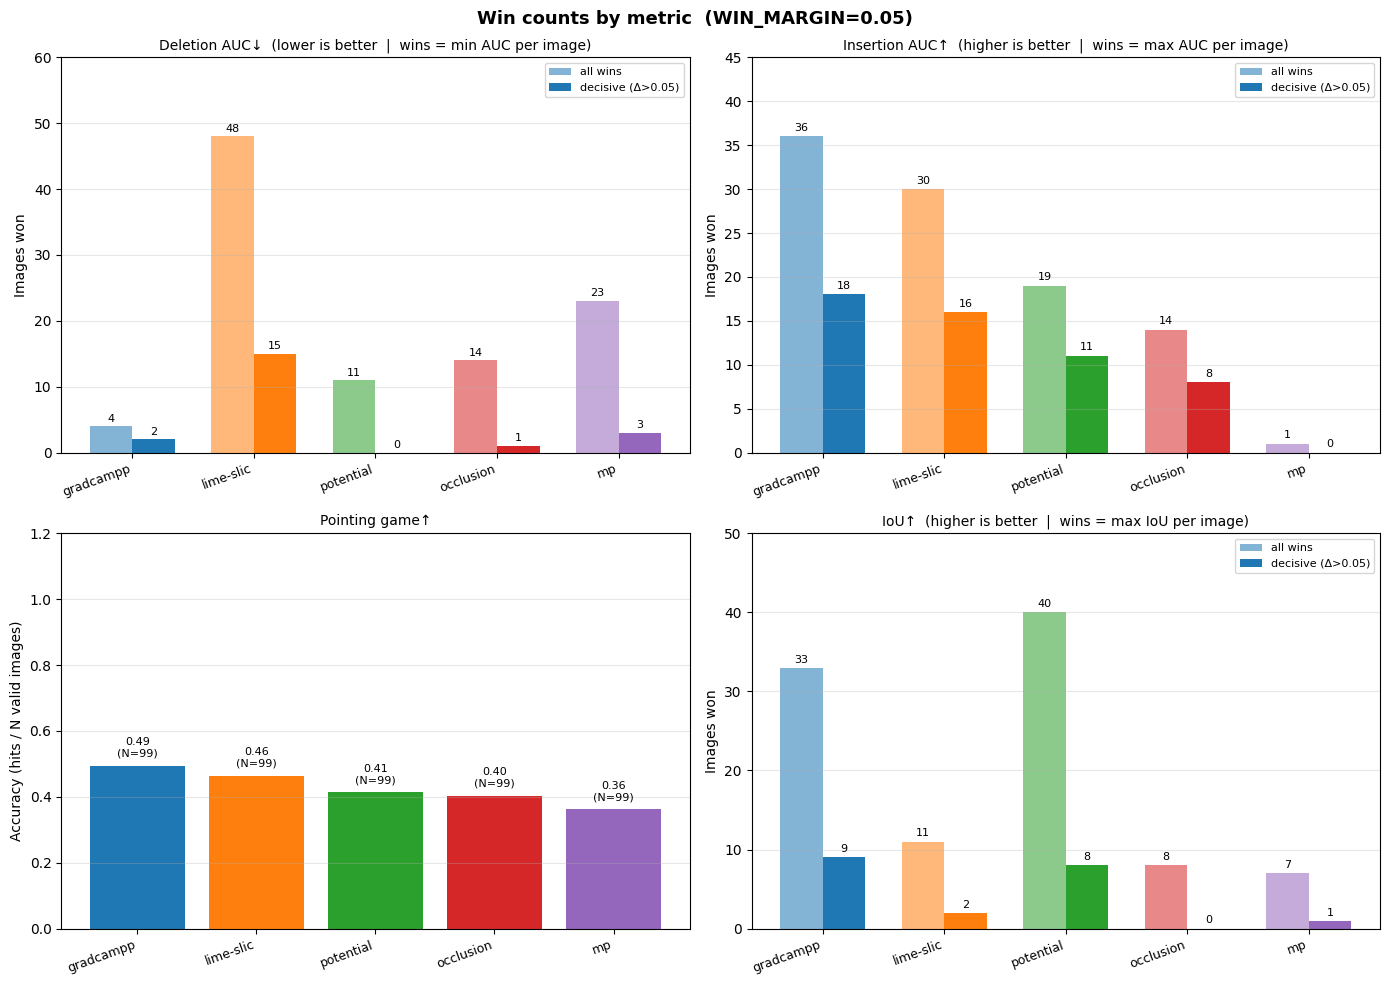

In [6]:
methods_ordered = list(table_sorted.index)

wins_del = count_wins(
    all_data, "deletion_auc", higher_is_better=False, margin=WIN_MARGIN
)
wins_ins = count_wins(
    all_data, "insertion_auc", higher_is_better=True, margin=WIN_MARGIN
)
wins_iou = count_wins(all_data, "iou", higher_is_better=True, margin=WIN_MARGIN)

pg_agg = all_data.groupby("method")["pointing_game"].agg(
    hits=lambda x: x.dropna().sum(), total=lambda x: x.notna().sum()
)
pg_acc = (pg_agg["hits"] / pg_agg["total"].clip(lower=1)).to_dict()
pg_n = pg_agg["total"].to_dict()

_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
_COLORS = {m: _cycle[i % len(_cycle)] for i, m in enumerate(methods_ordered)}


def _wins_bars(ax, wins_dict, methods, margin, title):
    x = np.arange(len(methods))
    w = 0.35
    all_w = [wins_dict.get(m, {}).get("wins", 0) for m in methods]
    dec_w = [wins_dict.get(m, {}).get("decisive", 0) for m in methods]
    b1 = ax.bar(
        x - w / 2,
        all_w,
        w,
        label="all wins",
        color=[_COLORS[m] for m in methods],
        alpha=0.55,
    )
    b2 = ax.bar(
        x + w / 2,
        dec_w,
        w,
        label=f"decisive (\u0394>{margin})",
        color=[_COLORS[m] for m in methods],
        alpha=1.0,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Images won")
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, max(max(all_w, default=0) * 1.25, 10))
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    for bar in list(b1) + list(b2):
        v = int(bar.get_height())
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.4,
            str(v),
            ha="center",
            va="bottom",
            fontsize=8,
        )


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f"Win counts by metric  (WIN_MARGIN={WIN_MARGIN})", fontsize=13, fontweight="bold"
)

_wins_bars(
    axes[0, 0],
    wins_del,
    methods_ordered,
    WIN_MARGIN,
    "Deletion AUC\u2193  (lower is better  |  wins = min AUC per image)",
)
_wins_bars(
    axes[0, 1],
    wins_ins,
    methods_ordered,
    WIN_MARGIN,
    "Insertion AUC\u2191  (higher is better  |  wins = max AUC per image)",
)
_wins_bars(
    axes[1, 1],
    wins_iou,
    methods_ordered,
    WIN_MARGIN,
    "IoU\u2191  (higher is better  |  wins = max IoU per image)",
)

ax = axes[1, 0]
x = np.arange(len(methods_ordered))
acc_vals = [pg_acc.get(m, 0.0) for m in methods_ordered]
ax.bar(x, acc_vals, color=[_COLORS[m] for m in methods_ordered])
ax.set_xticks(x)
ax.set_xticklabels(methods_ordered, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Accuracy (hits / N valid images)")
ax.set_title("Pointing game\u2191", fontsize=10)
ax.set_ylim(0, 1.2)
for i, m in enumerate(methods_ordered):
    v = pg_acc.get(m, 0.0)
    n = int(pg_n.get(m, 0))
    ax.text(i, v + 0.02, f"{v:.2f}\n(N={n})", ha="center", va="bottom", fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Per-image metric distributions

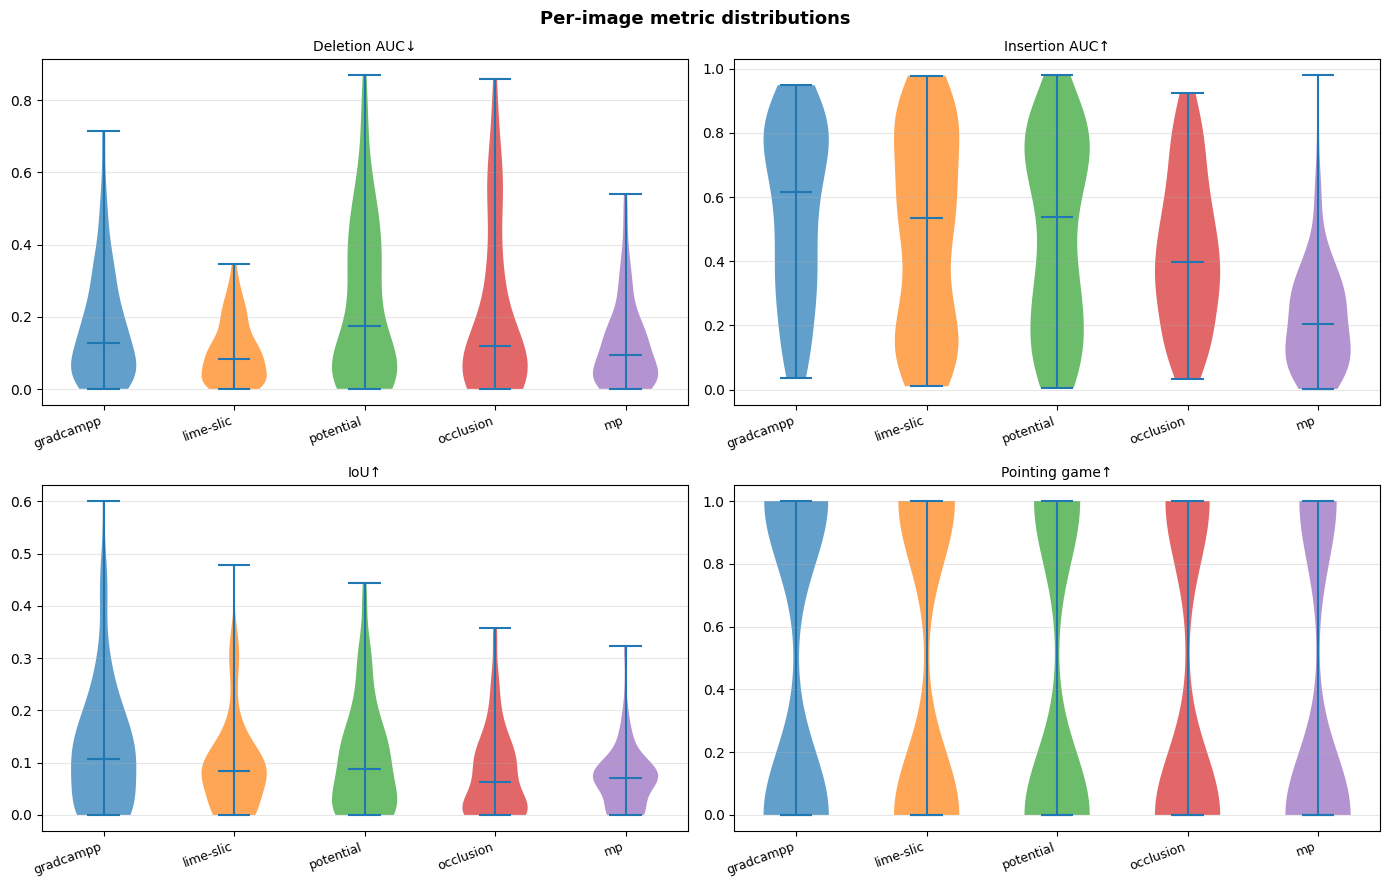

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Per-image metric distributions", fontsize=13, fontweight="bold")

metric_plots = [
    ("deletion_auc", "Deletion AUC\u2193", (0, 0)),
    ("insertion_auc", "Insertion AUC\u2191", (0, 1)),
    ("iou", "IoU\u2191", (1, 0)),
    ("pointing_game", "Pointing game\u2191", (1, 1)),
]

for metric_col, title, (r, c) in metric_plots:
    ax = axes[r, c]
    data_per = [
        all_data.loc[all_data["method"] == m, metric_col].dropna().values
        for m in methods_ordered
    ]
    non_empty = [(i, d) for i, d in enumerate(data_per) if len(d) > 1]
    if non_empty:
        positions, datasets = zip(*non_empty, strict=False)
        parts = ax.violinplot(
            list(datasets), positions=list(positions), showmedians=True
        )
        for i, pc in enumerate(parts["bodies"]):
            pc.set_facecolor(_COLORS[methods_ordered[positions[i]]])
            pc.set_alpha(0.7)
    ax.set_xticks(range(len(methods_ordered)))
    ax.set_xticklabels(methods_ordered, rotation=20, ha="right", fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()